In [105]:
import numpy as np
import pandas as pd

# data preprocessing

In [106]:
df = pd.read_csv('/content/sample_data/placement.csv')

In [107]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [108]:
df.shape

(100, 4)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


## removing the unnecessary column

In [110]:
df = df.drop('Unnamed: 0',axis=1)

also we can use : df = df.iloc[:,1:]

In [111]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


## **ploting** a graphs

In [112]:
import matplotlib.pyplot as plt

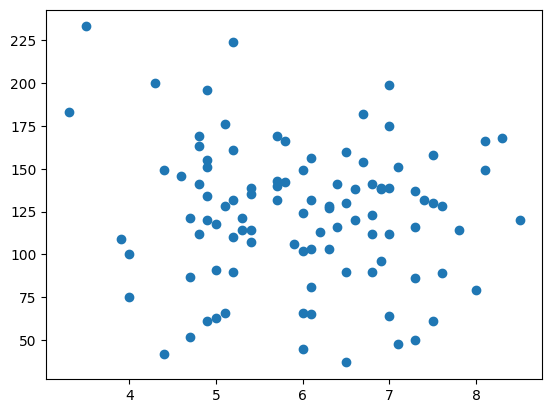

In [113]:
plt.scatter(df['cgpa'],df['iq'])

## color to the placement : 0 -> not placed -> purple and 1->placed -> yellow

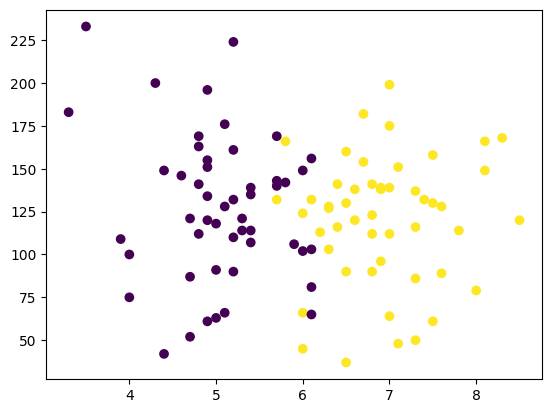

In [114]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

# split data into training and testing

In [115]:
x = df.iloc[:,0:2]

In [116]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [117]:
y = df.iloc[:,-1]

In [118]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [119]:
from sklearn.model_selection import train_test_split

In [120]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.1)

In [121]:
x_test

,cgpa,iq
43,6.8,141.0
24,4.7,121.0
54,6.4,141.0
42,7.6,89.0
6,5.7,143.0
23,4.7,87.0
83,7.5,130.0
40,4.9,134.0
91,7.5,158.0
81,5.4,107.0


# Scale the data

In [122]:
from sklearn.preprocessing import StandardScaler

In [123]:
scaler =StandardScaler()

In [124]:
x_train = scaler.fit_transform(x_train)

In [125]:
x_train

array([[ 0.02050495, -1.90285731],
       [ 0.72353173, -0.27692142],
       [-0.15525175,  0.45110958],
       [ 0.1083833 , -1.02922012],
       [-0.85827853, -0.13131522],
       [-0.2431301 ,  1.10633747],
       [-2.17645375,  2.65947026],
       [-0.15525175,  1.03353437],
       [-0.77040018,  0.11136178],
       [ 1.16292347, -0.17985062],
       [ 0.1083833 ,  0.79085737],
       [-0.94615688,  1.76156537],
       [ 2.21746365, -0.08277982],
       [ 2.04170695,  1.08206977],
       [ 1.33868017, -1.51457411],
       [ 0.81141008, -0.66520462],
       [-1.03403523, -0.27692142],
       [ 0.89928843,  0.37830648],
       [ 0.45989669,  0.15989718],
       [-0.50676514,  0.37830648],
       [ 0.72353173, -0.00997672],
       [-1.03403523,  1.10633747],
       [ 0.89928843,  1.83436847],
       [-2.35221045,  1.44608527],
       [ 0.89928843, -1.44177101],
       [ 0.02050495,  0.01429098],
       [ 0.45989669, -2.09699891],
       [ 0.37201834, -0.17985062],
       [ 0.1083833 ,

In [126]:
x_test = scaler.transform(x_test)

In [127]:
x_test

array([[ 0.72353173,  0.42684188],
       [-1.12191358, -0.05851212],
       [ 0.37201834,  0.42684188],
       [ 1.42655852, -0.83507852],
       [-0.2431301 ,  0.47537728],
       [-1.12191358, -0.88361392],
       [ 1.33868017,  0.15989718],
       [-0.94615688,  0.25696798],
       [ 1.33868017,  0.83939277],
       [-0.50676514, -0.39825992]])

# Train the model

In [128]:
# Logistic  Regression

from sklearn.linear_model import LogisticRegression

In [129]:
model = LogisticRegression()

In [130]:
model = model.fit(x_train,y_train)

In [131]:
y_pred = model.predict(x_test)

In [132]:
y_test

,placement
43,1
24,0
54,1
42,1
6,0
23,0
83,1
40,0
91,1
81,0


# Accuracy

In [133]:
from sklearn.metrics import accuracy_score

In [134]:
accuracy_score(y_test, y_pred)

1.0

# Decision Boundary

In [135]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

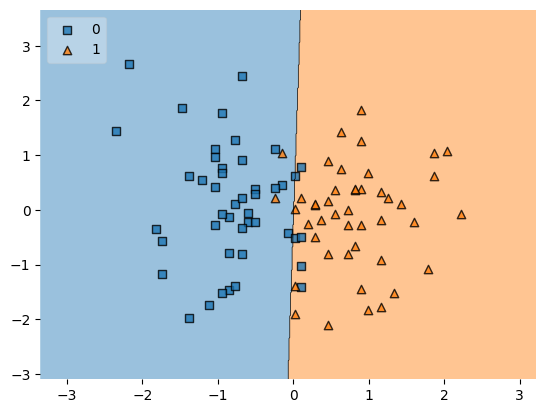

In [136]:
plot_decision_regions(x_train, y_train.values, clf=model, legend=2)